In [1]:
import pandas as pd

# ---------- CONFIG ----------
traffic_path = "traffic.csv"
weather_path = "weather.csv"
pollution_path = "pollution.csv"

# If column names differ, change these later
POSSIBLE_TIME_COLUMNS = ["timestamp", "date", "datetime", "time"]

# ---------- HELPER FUNCTION ----------
def analyze_dataset(name, path):
    print(f"\n{'='*50}")
    print(f"DATASET: {name}")
    print(f"{'='*50}")

    # Load
    df = pd.read_csv(path)

    # Basic info
    print("\n--- Shape ---")
    print(df.shape)

    print("\n--- Columns ---")
    print(df.columns.tolist())

    print("\n--- Head ---")
    print(df.head())

    print("\n--- Info ---")
    print(df.info())

    # Try to find time column
    time_col = None
    for col in df.columns:
        if col.lower() in POSSIBLE_TIME_COLUMNS:
            time_col = col
            break

    if time_col:
        print(f"\n--- Detected time column: {time_col} ---")

        # Convert to datetime
        try:
            df[time_col] = pd.to_datetime(df[time_col])
            print("Converted to datetime successfully")

            print("\n--- Time range ---")
            print("Min:", df[time_col].min())
            print("Max:", df[time_col].max())

        except Exception as e:
            print("Failed to convert time column:", e)
    else:
        print("\n--- No obvious time column detected ---")

    # Missing values
    print("\n--- Missing values ---")
    print(df.isnull().sum())

    # Numeric stats
    print("\n--- Describe (numeric) ---")
    print(df.describe())

    return df

In [2]:
# ---------- RUN ----------
traffic_df = analyze_dataset("TRAFFIC", traffic_path)
weather_df = analyze_dataset("WEATHER", weather_path)
pollution_df = analyze_dataset("POLLUTION", pollution_path)


DATASET: TRAFFIC

--- Shape ---
(1875154, 14)

--- Columns ---
['RequestID', 'Boro', 'Yr', 'M', 'D', 'HH', 'MM', 'Vol', 'SegmentID', 'WktGeom', 'street', 'fromSt', 'toSt', 'Direction']

--- Head ---
   RequestID    Boro    Yr  M  D  HH  MM Vol  SegmentID  \
0      12512  Queens  2013  3  7   4  15   5      55135   
1      12512  Queens  2013  3  7   4  30   8      55135   
2      12512  Queens  2013  3  7   4  45   8      55135   
3      12512  Queens  2013  3  7   5   0   7      55135   
4      12512  Queens  2013  3  7   5  15   9      55135   

                      WktGeom  street     fromSt           toSt Direction  
0  POINT (1035363.4 185093.4)  122 PL  SUTTER AV  ROCKAWAY BLVD        SB  
1  POINT (1035363.4 185093.4)  122 PL  SUTTER AV  ROCKAWAY BLVD        SB  
2  POINT (1035363.4 185093.4)  122 PL  SUTTER AV  ROCKAWAY BLVD        SB  
3  POINT (1035363.4 185093.4)  122 PL  SUTTER AV  ROCKAWAY BLVD        SB  
4  POINT (1035363.4 185093.4)  122 PL  SUTTER AV  ROCKAWAY BLVD  

In [4]:
import pandas as pd

traffic = pd.read_csv("traffic.csv")

# Fix volume (it's string now)
traffic['Vol'] = pd.to_numeric(traffic['Vol'], errors='coerce')

# Build timestamp
traffic['timestamp'] = pd.to_datetime(
    traffic[['Yr', 'M', 'D', 'HH', 'MM']]
    .rename(columns={
        'Yr': 'year', 'M': 'month', 'D': 'day',
        'HH': 'hour', 'MM': 'minute'
    })
)

# Keep only needed columns
traffic = traffic[['timestamp', 'Vol']]

# Convert to hourly (sum makes sense for traffic)
traffic = traffic.set_index('timestamp').resample('1h').sum().reset_index()
traffic.rename(columns={'Vol': 'traffic_volume'}, inplace=True)

traffic.head()

,timestamp,traffic_volume
0,2000-01-01 00:00:00,962.0
1,2000-01-01 01:00:00,1359.0
2,2000-01-01 02:00:00,1488.0
3,2000-01-01 03:00:00,1501.0
4,2000-01-01 04:00:00,1368.0


In [7]:
weather = pd.read_csv("weather.csv")

weather['timestamp'] = pd.to_datetime(weather['date'])

# Keep only relevant columns
weather = weather[['timestamp', 'tavg', 'prcp']]

# Set index
weather = weather.set_index('timestamp')

# Convert daily → hourly by forward filling
weather = weather.resample('1h').ffill().reset_index()

# Rename columns
weather.rename(columns={
    'tavg': 'temperature',
    'prcp': 'precipitation'
}, inplace=True)

# Fill precipitation NaN with 0 (means no rain)
weather['precipitation'] = weather['precipitation'].fillna(0)

weather.head()

,timestamp,temperature,precipitation
0,2020-01-01 00:00:00,3.6,0.0
1,2020-01-01 01:00:00,3.6,0.0
2,2020-01-01 02:00:00,3.6,0.0
3,2020-01-01 03:00:00,3.6,0.0
4,2020-01-01 04:00:00,3.6,0.0


In [8]:
pollution = pd.read_csv("pollution.csv")

# Convert timestamp
pollution['timestamp'] = pd.to_datetime(pollution['datetimeUtc'])

# Keep only relevant columns
pollution = pollution[['timestamp', 'parameter', 'value']]

# Pivot → columns = parameters (pm1, pm2.5, etc.)
pollution = pollution.pivot_table(
    index='timestamp',
    columns='parameter',
    values='value',
    aggfunc='mean'
).reset_index()

# Optional: keep only one pollutant (simpler)
if 'pm25' in pollution.columns:
    pollution = pollution[['timestamp', 'pm25']]
elif 'pm1' in pollution.columns:
    pollution = pollution[['timestamp', 'pm1']]

# Resample to hourly (already hourly, but safe)
pollution = pollution.set_index('timestamp').resample('1h').mean().reset_index()

pollution.head()

parameter,timestamp,pm25
0,2025-12-16 04:00:00+00:00,15.696000
1,2025-12-16 05:00:00+00:00,16.127667
2,2025-12-16 06:00:00+00:00,16.152500
3,2025-12-16 07:00:00+00:00,26.174833
4,2025-12-16 08:00:00+00:00,29.644333


In [14]:
pollution['timestamp'] = pd.to_datetime(pollution['timestamp'])

# REMOVE timezone
pollution['timestamp'] = pollution['timestamp'].dt.tz_localize(None)

In [15]:
df = traffic.merge(weather, on='timestamp', how='inner')
df = df.merge(pollution, on='timestamp', how='inner')

In [16]:
# Handle missing values
df = df.interpolate()

# Drop any remaining NaNs
df = df.dropna()

# Sort
df = df.sort_values('timestamp')

print(df.head())
print(df.shape)

            timestamp  traffic_volume  temperature  precipitation       pm25
0 2025-12-16 04:00:00             0.0         -1.0            0.0  15.696000
1 2025-12-16 05:00:00             0.0         -1.0            0.0  16.127667
2 2025-12-16 06:00:00             0.0         -1.0            0.0  16.152500
3 2025-12-16 07:00:00             0.0         -1.0            0.0  26.174833
4 2025-12-16 08:00:00             0.0         -1.0            0.0  29.644333
(1004, 5)


In [19]:
import matplotlib.pyplot as plt

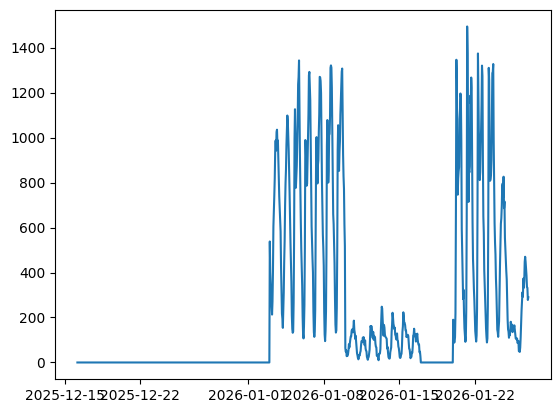

In [20]:
plt.plot(df['timestamp'], df['traffic_volume'], label='Traffic Volume')

In [21]:
df.tail()

,timestamp,traffic_volume,temperature,precipitation,pm25
999,2026-01-26 19:00:00,386.0,-3.9,0.4,3.194167
1000,2026-01-26 20:00:00,335.0,-3.9,0.4,3.566000
1001,2026-01-26 21:00:00,332.0,-3.9,0.4,1.731000
1002,2026-01-26 22:00:00,278.0,-3.9,0.4,0.700000
1003,2026-01-26 23:00:00,290.0,-3.9,0.4,0.972500
